In [1]:
import matplotlib.pyplot as plt
import numpy as np

import freq_statespace as fss

import best_linear_approximation as bla

raw_data = np.load("closed_loop_controller_id.npz")

r = raw_data["r"][:, [1], :]
u = raw_data["u"][:, [1], :, :]
e = raw_data["e"][:, [1], :, :]

# select onl

print(raw_data["message"])

# r -= np.mean(r, axis=(0, 2), keepdims=True)
# e -= np.mean(e, axis=(0, 2, 3), keepdims=True)
# u -= np.mean(u, axis=(0, 2, 3), keepdims=True)

fs = float(raw_data["fs"])

G_bla = bla.robust.closed_loop(r=r, u=e, y=u, fs=fs, independent_subexperiments=True)

id_data_c = fss.create_data_object_from_bla(G_bla)

print(G_bla.spectra.Y.total_equation_error.as_percentage)
print(G_bla.spectra.Y.total.as_percentage)
print(G_bla.spectra.Y.noise.as_percentage)

Deployed experiment 75938075: 3 rev/s setpoint + 0.5 rev/s RMS multisine (0.09765625 to 9.9609375 Hz), load amplitude 10%; 10 realizations x 4 periods at 100 Hz.
Detected 102 excited frequency bins from 9.77e-02 Hz to 9.96 Hz; every bin in that interval is excited (full multisine).


/home/merijn/Documents/freq-statespace/.venv/lib/python3.12/site-packages/best_linear_approximation/_argument_preparation.py:130: PossibleExcitationAmplitudeMismatchWarning: The relative mismatch between all 9 adjacent channel-realization pairs exceeds the threshold of 2.50%. This may indicate an excitation-amplitude change between realizations. Aggregated relative differences: [11.03%, 11.61%, 6.97%, 8.60%, 10.09%, 10.44%, 11.21%, 10.70%, 10.93%].
  _warn_if_excitation_amplitude_mismatch(r if r is not None else u, max_bin)
/home/merijn/Documents/freq-statespace/.venv/lib/python3.12/site-packages/best_linear_approximation/_argument_preparation.py:132: PossiblePeriodMismatchWarning: The relative spectral mismatch between all 3 adjacent period pairs exceeds the threshold of 2.50%. This may indicate transients, drift, changing excitation, or period-alignment issues. Aggregated relative differences: [59.06%, 53.53%, 54.85%].
  _warn_if_output_spectra_mismatch(y, max_bin)


[20.58761948]
[39.4385895]
[35.08365947]


<div align="center">
<img src="dual-motor-drivetrain-block-diagram.drawio.svg" alt="Frequency response" width="800">
</div>

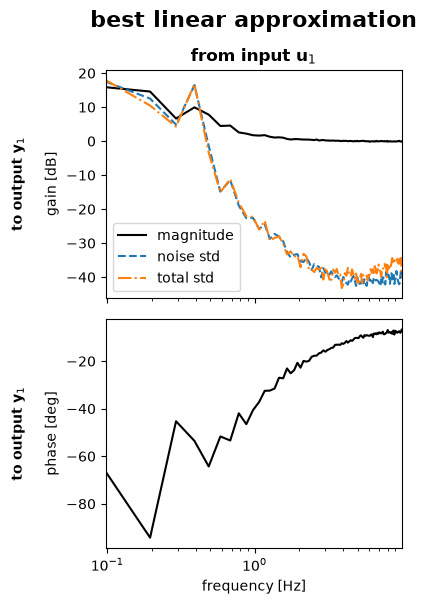

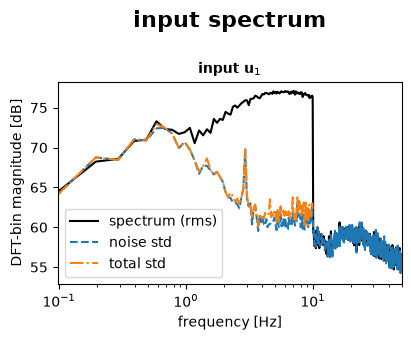

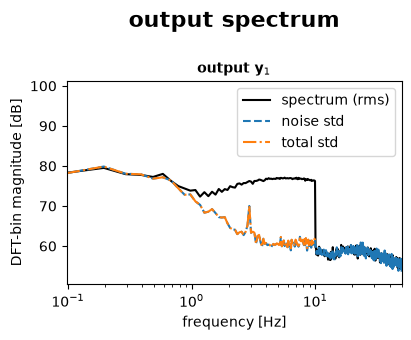

In [2]:


from bla_analysis import plot_bla_analysis

plot_bla_analysis(G_bla)


In [3]:
# Step 1: BLA estimation
nx = 1  # state dimension
bla_c_right = fss.lin.subspace_id(id_data_c, nx)
bla_c_right = fss.lin.optimize(bla_c_right, id_data_c)


norm = fss.Normalizer(u_mean=0, u_std=1, y_mean=0, y_std=1)
bla_c_left = fss.ModelBLA(A=np.reshape(1, (1, 1)), B_u=np.reshape(1, (1, 1)), C_y=np.reshape(0.05, (1, 1)), D_yu=np.reshape(1.025, (1, 1)), norm=norm, ts=1/fs)


=============== Frequency-domain subspace identification ===============
BLA simulation error: 20.02%.

=========================== BLA optimization ===========================
Starting iterative optimization...
    Iter 1 | loss = 3.4390e+00
    Iter 2 | loss = 3.4390e+00
    Iter 3 | loss = 3.4293e+00
    Iter 4 | loss = 3.4289e+00
    Iter 5 | loss = 3.4288e+00
    Iter 6 | loss = 3.4288e+00
    Iter 7 | loss = 3.4288e+00
    Iter 8 | loss = 3.4288e+00
    Iter 9 | loss = 3.4288e+00
    Iter 10 | loss = 3.4288e+00
Optimization completed in 0.04s (10 iterations, 1.64ms/iter).

BLA simulation error: 114.37%.



In [4]:
print(bla_c_right.norm.y_std)

[98.19257288]


1


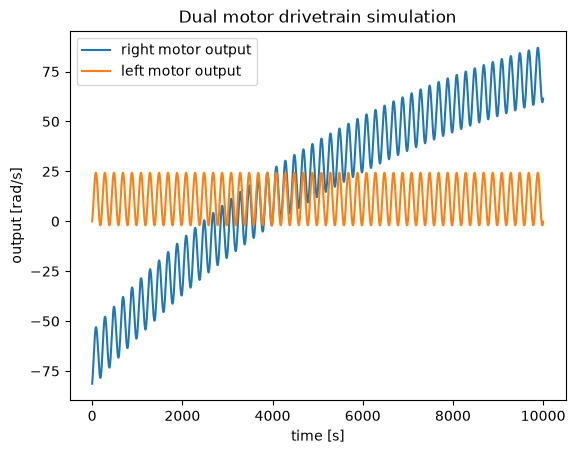

In [5]:
t  = np.arange(0, 100, 1/fs)
u_c = 7 * np.sin(2 * np.pi * 0.5 * t)

print(bla_c_right.B_u.shape[1])

y_right_c = bla_c_right.simulate(u_c)[0]
y_left_c = bla_c_left.simulate(u_c)[0]

# %matplotlib qt5
plt.figure()
# plt.plot(e[:,0,0,0], label="input")
plt.plot(y_right_c, label="right motor output")
plt.plot(y_left_c, label="left motor output")
plt.xlabel("time [s]")
plt.ylabel("output [rad/s]")
plt.title("Dual motor drivetrain simulation")
plt.legend()
plt.show()


['left' 'top' 'right']
Deployed experiment 37854498: 3 rev/s setpoint. 30% RMS feedforward multisine (0.09765625 to 9.9609375 Hz), load amplitude 10%; 10 realizations x 4 periods at 100 Hz.


Detected 102 excited frequency bins from 9.77e-02 Hz to 9.96 Hz; every bin in that interval is excited (full multisine).


/home/merijn/Documents/freq-statespace/.venv/lib/python3.12/site-packages/best_linear_approximation/_argument_preparation.py:132: PossiblePeriodMismatchWarning: The relative spectral mismatch between all 3 adjacent period pairs exceeds the threshold of 2.50%. This may indicate transients, drift, changing excitation, or period-alignment issues. Aggregated relative differences: [29.13%, 25.19%, 25.30%].
  _warn_if_output_spectra_mismatch(y, max_bin)


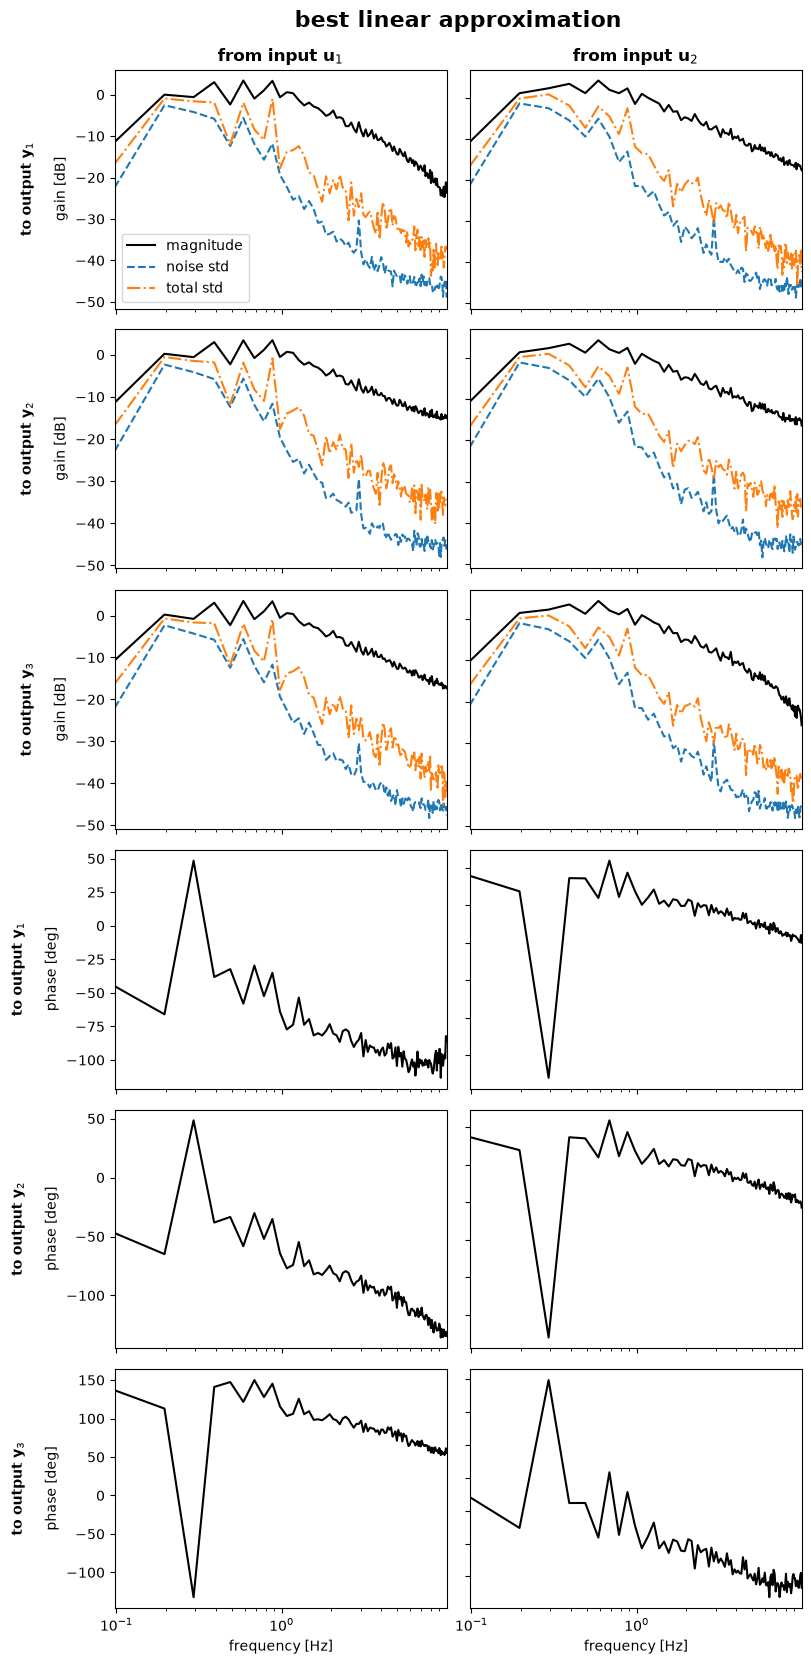

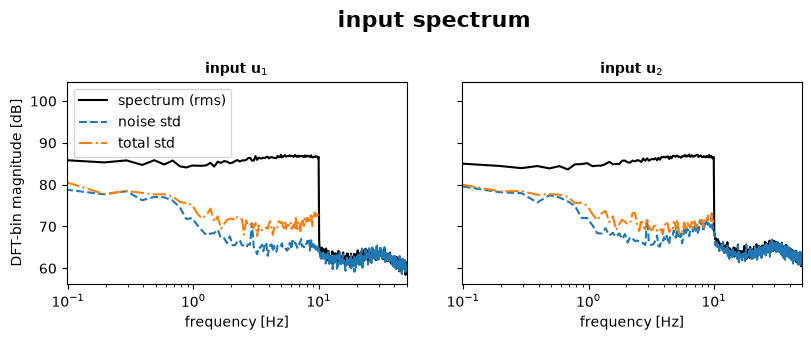

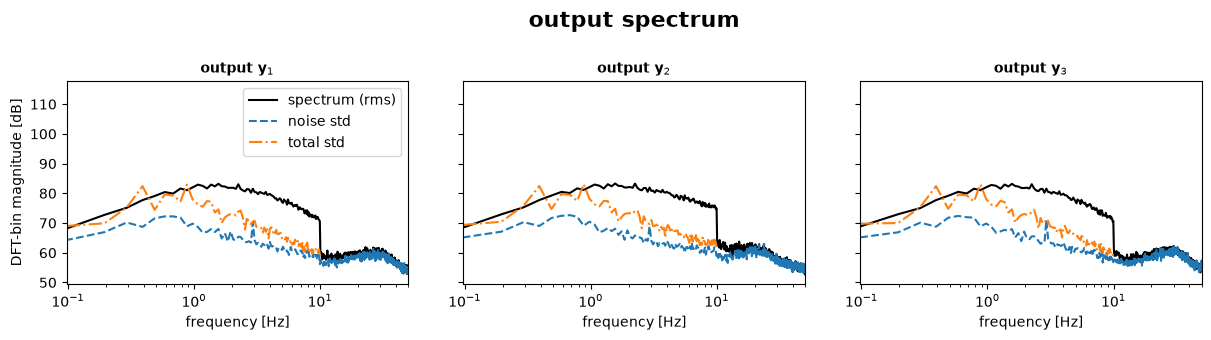

In [6]:
import numpy as np

raw_data = np.load("closed_loop_plant_id_100Nm_load.npz")

r_train, r_test = raw_data["r"], raw_data["r"][..., 8:]
u_train, u_test = raw_data["u"], raw_data["u"][..., 8:, :]
y_train, y_test = raw_data["y"], raw_data["y"][..., 8:, :]


raw_data_test = np.load("closed_loop_plant_id_no_load.npz")

r_test = raw_data_test["r"]
u_test = raw_data_test["u"]
y_test = raw_data_test["y"]

# r_train -= np.mean(r_train, axis=(0, 2), keepdims=True)
# u_train -= np.mean(u_train, axis=(0, 2, 3), keepdims=True)
# y_train -= np.mean(y_train, axis=(0, 2, 3), keepdims=True)

# r_test -= np.mean(r_train, axis=(0, 2), keepdims=True)
# u_test -= np.mean(u_train, axis=(0, 2, 3), keepdims=True)
# y_test -= np.mean(y_train, axis=(0, 2, 3), keepdims=True)

print(raw_data["output_motor_ids"])

# select onl

print(raw_data["message"])


G_bla = bla.robust.closed_loop(r=r_train, u=u_train, y=y_train, fs=fs, independent_subexperiments=True)



plot_bla_analysis(G_bla)

id_data_p = fss.create_data_object_from_bla(G_bla)

In [14]:
r_train_zero_mean = r_train - np.mean(r_train, axis=(0, 2), keepdims=True)
u_train_zero_mean = u_train - np.mean(u_train, axis=(0, 2, 3), keepdims=True)
y_train_zero_mean = y_train - np.mean(y_train, axis=(0, 2, 3), keepdims=True)

G_bla_zero_mean = bla.robust.closed_loop(r=r_train_zero_mean, u=u_train_zero_mean, y=y_train_zero_mean, fs=fs, independent_subexperiments=True)

print(G_bla_zero_mean.spectra.Y.total_equation_error.as_percentage)
print(G_bla_zero_mean.spectra.Y.total.as_percentage)
print(G_bla_zero_mean.spectra.Y.noise.as_percentage)

Detected 102 excited frequency bins from 9.77e-02 Hz to 9.96 Hz; every bin in that interval is excited (full multisine).
[69.2603605  63.64921602 69.00787826]
[44.05798129 41.6497334  44.15693024]
[26.28323191 25.20080793 27.07002862]


/home/merijn/Documents/freq-statespace/.venv/lib/python3.12/site-packages/best_linear_approximation/_argument_preparation.py:132: PossiblePeriodMismatchWarning: The relative spectral mismatch between all 3 adjacent period pairs exceeds the threshold of 2.50%. This may indicate transients, drift, changing excitation, or period-alignment issues. Aggregated relative differences: [29.13%, 25.19%, 25.30%].
  _warn_if_output_spectra_mismatch(y, max_bin)


In [8]:
# Step 1: BLA estimation
nx = 3  # state dimension
bla_p = fss.lin.subspace_id(id_data_p, nx, estimate_direct_feedthrough=False)

bla_p = fss.lin.optimize(bla_p, id_data_p, estimate_direct_feedthrough=False, enforce_stability=True)


=============== Frequency-domain subspace identification ===============
BLA simulation error:
    output 1: 69.51%.
    output 2: 74.57%.
    output 3: 69.88%.

================= Stability-enforced BLA optimization ==================
Starting iterative optimization...
    Iter 1 | loss = 8.7302e+00
    Iter 2 | loss = 8.7302e+00
    Iter 3 | loss = 6.4732e+00
    Iter 4 | loss = 5.4690e+00
    Iter 5 | loss = 5.2429e+00
    Iter 6 | loss = 4.6199e+00
    Iter 7 | loss = 4.0977e+00
    Iter 8 | loss = 4.0693e+00
    Iter 9 | loss = 4.0604e+00
    Iter 10 | loss = 4.0557e+00
    Iter 11 | loss = 4.0527e+00
    Iter 12 | loss = 4.0505e+00
    Iter 13 | loss = 4.0488e+00
    Iter 14 | loss = 4.0475e+00
    Iter 15 | loss = 4.0465e+00
    Iter 16 | loss = 4.0456e+00
    Iter 17 | loss = 4.0449e+00
    Iter 18 | loss = 4.0443e+00
    Iter 19 | loss = 4.0429e+00
    Iter 20 | loss = 4.0419e+00
    Iter 21 | loss = 4.0404e+00
    Iter 22 | loss = 4.0396e+00
    Iter 23 | loss = 4.0389e+00
   

In [9]:
import jax
# Step 2: Nonlinear optimization
neural_net = fss.static.NeuralNetwork(
    nw=1, nz=3, layers=1, neurons_per_layer=64, activation=jax.nn.relu
)

nllfr = fss.nonlin.connect(bla_p, neural_net)
nllfr = fss.nonlin.optimize(nllfr, id_data_p, estimate_direct_feedthrough=False)

========================= NL-LFR optimization ==========================
Starting iterative optimization...
    BLA loss: 6.4256e+00
    Iter 1 | loss = 6.4323e+00
    Iter 2 | loss = 6.4323e+00
    Iter 3 | loss = 4.0055e+00
    Iter 4 | loss = 3.7189e+00
    Iter 5 | loss = 3.7189e+00
    Iter 6 | loss = 3.7189e+00
    Iter 7 | loss = 3.7189e+00
    Iter 8 | loss = 3.7189e+00
    Iter 9 | loss = 3.5246e+00
    Iter 10 | loss = 3.3922e+00
    Iter 11 | loss = 3.1766e+00
    Iter 12 | loss = 2.9109e+00
    Iter 13 | loss = 2.7301e+00
    Iter 14 | loss = 2.5895e+00
    Iter 15 | loss = 2.4365e+00
    Iter 16 | loss = 2.4365e+00
    Iter 17 | loss = 2.3703e+00
    Iter 18 | loss = 2.3660e+00
    Iter 19 | loss = 2.3660e+00
    Iter 20 | loss = 2.3660e+00
    Iter 21 | loss = 2.2195e+00
    Iter 22 | loss = 2.2195e+00
    Iter 23 | loss = 2.2041e+00
    Iter 24 | loss = 2.1486e+00
    Iter 25 | loss = 2.1407e+00
    Iter 26 | loss = 2.1269e+00
    Iter 27 | loss = 2.1008e+00
    Iter 28 

In [ ]:
from simulate import simulate, simulate2

K_left = bla_c_left
K_right = bla_c_right

n_samples_test, _, n_experiments_test, n_periods_test = y_test.shape

plant = nllfr
setpoint = 3 * 2* np.pi * 28

r = np.ones((n_samples_test, 1, n_experiments_test, n_periods_test)) * setpoint
r_1_right = np.zeros((n_samples_test, 1, n_experiments_test, n_periods_test))
r_2 = np.repeat(r_test[..., None], n_periods_test, axis=3)

y_sim_test = simulate(K_left, K_right, plant, r, r_1_right, r_2)

In [ ]:
y_sim_test2 = simulate2(K_left, K_right, plant, r, r_1_right, r_2)

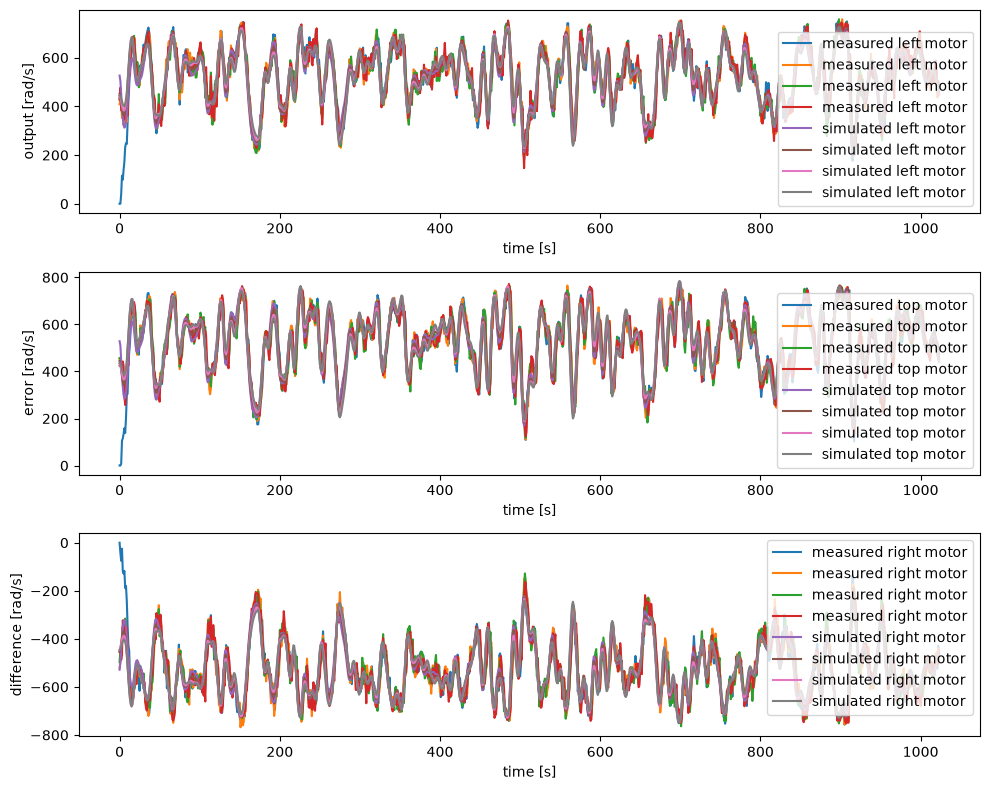

In [13]:
import matplotlib.pyplot as plt

# 3 by 1 subplots
plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(np.squeeze(y_test[:, 0, 0, :]), label='measured left motor')
plt.plot(np.squeeze(y_sim_test[:, 0, 0, :]), label='simulated left motor')
plt.xlabel("time [s]")
plt.ylabel("output [rad/s]")
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(np.squeeze(y_test[:, 1, 0, :]), label='measured top motor')
plt.plot(np.squeeze(y_sim_test[:, 1, 0, :]), label='simulated top motor')
plt.xlabel("time [s]")
plt.ylabel("error [rad/s]")
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(np.squeeze(y_test[:, 2, 0, :]), label='measured right motor')
plt.plot(np.squeeze(y_sim_test[:, 2, 0, :]), label='simulated right motor')
plt.xlabel("time [s]")
plt.ylabel("difference [rad/s]")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# y_test -= np.mean(y_test, axis=(0, 2, 3), keepdims=True)
# y_sim_test -= np.mean(y_sim_test, axis=(0, 2, 3), keepdims=True)

error = y_test - y_sim_test


# mse = np.mean(error**2, axis=(0, 2, 3))
# norm = np.mean(y_test**2, axis=(0, 2, 3))

mse = np.std(error, axis=(0, 2, 3))
norm = np.std(y_test, axis=(0, 2, 3))

nrmse = 100 * (mse / norm)  # as a percentage

ny = 3
if ny == 1:
    print(f"Closed-loop simulation error: {nrmse[0]:.2f}%.")
else:
    print(f"Closed-loop simulation error:")
    for k in range(ny):
        print(f"    output {k + 1}: {nrmse[k]:.2f}%.")
print("")




Closed-loop simulation error:
    output 1: 31.60%.
    output 2: 34.26%.
    output 3: 37.49%.

